In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

from imblearn.over_sampling import SMOTE

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier

from xgboost import XGBClassifier

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_excel("perfect_final_data_for_multilevel_analysis.xlsx")

df.head()

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
count,8502.00000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,...,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000,8502.000000
mean,336.40120,57.354387,32.862856,4.183369,4.387556,1.654317,1.594919,25.852035,1.141731,0.095036,...,1.454364,1.336627,1.057281,2.407786,2.651964,1.783580,1.047165,0.893907,2.366384,0.479064
std,196.25096,38.108571,8.397406,1.702670,2.233568,0.475619,0.892459,19.535639,1.501135,0.370544,...,0.615048,0.482194,0.642485,1.227321,1.756871,0.698343,0.891350,0.307974,0.764901,0.499591
min,1.00000,1.000000,15.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,162.00000,26.000000,26.000000,3.000000,2.000000,1.000000,1.000000,21.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,2.000000,0.000000
50%,335.00000,54.000000,33.000000,4.000000,4.000000,2.000000,2.000000,21.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,2.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000
75%,507.00000,84.000000,40.000000,6.000000,6.000000,2.000000,2.000000,21.000000,1.000000,0.000000,...,2.000000,2.000000,1.000000,4.000000,4.000000,2.000000,2.000000,1.000000,3.000000,1.000000
max,675.00000,215.000000,49.000000,7.000000,8.000000,2.000000,3.000000,97.000000,96.000000,2.000000,...,3.000000,2.000000,2.000000,4.000000,6.000000,4.000000,2.000000,1.000000,4.000000,1.000000


In [37]:
features = [

'V013',
'V024',
'V025',
'V106',
'Drinking_water',
# 'Religion_status',
'Media_acccess',
'Wealth_Status',
'Number_of_children',
'Respondent_Age_first_birth',
# 'Living_children',
'Birth_Interval',
'contraceptive_use',
# 'V404',
'husband_education',
'profession_of_husband',
'Age_of_husband',
'V714'

]

X = df[features]
y = df['BMI']

In [38]:
print(Counter(y))

Counter({2: 4469, 3: 2533, 1: 806, 4: 694})


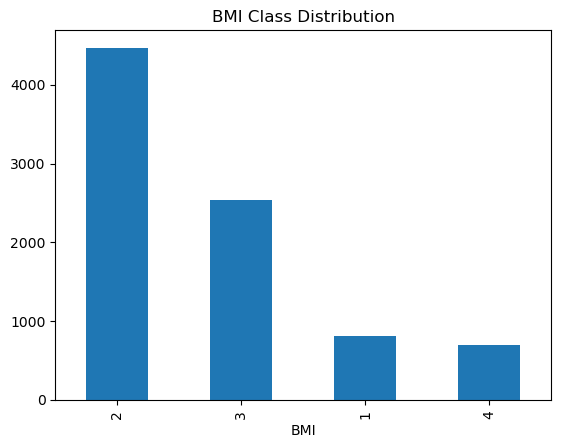

In [39]:
pd.Series(y).value_counts().plot(kind='bar')
plt.title("BMI Class Distribution")
plt.show()

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [41]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_smote))

After SMOTE: Counter({3: 3128, 2: 3128, 4: 3128, 1: 3128})


In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [43]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Decision Tree Accuracy: 0.3586828694629557
              precision    recall  f1-score   support

           1       0.14      0.21      0.17       242
           2       0.54      0.43      0.48      1341
           3       0.33      0.34      0.33       760
           4       0.09      0.14      0.11       208

    accuracy                           0.36      2551
   macro avg       0.27      0.28      0.27      2551
weighted avg       0.40      0.36      0.38      2551

[[ 50 112  55  25]
 [215 579 388 159]
 [ 75 298 256 131]
 [ 19  78  81  30]]


In [44]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.40337122696981575
              precision    recall  f1-score   support

           1       0.14      0.17      0.15       242
           2       0.55      0.53      0.54      1341
           3       0.35      0.32      0.33       760
           4       0.13      0.17      0.15       208

    accuracy                           0.40      2551
   macro avg       0.29      0.30      0.29      2551
weighted avg       0.42      0.40      0.41      2551



In [45]:
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train_scaled, y_train_smote)

y_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.31164249313994513
              precision    recall  f1-score   support

           1       0.12      0.32      0.18       242
           2       0.55      0.33      0.42      1341
           3       0.35      0.29      0.32       760
           4       0.10      0.23      0.14       208

    accuracy                           0.31      2551
   macro avg       0.28      0.29      0.26      2551
weighted avg       0.41      0.31      0.34      2551



In [46]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train_smote)

y_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.33790670325362604
              precision    recall  f1-score   support

           1       0.16      0.36      0.22       242
           2       0.56      0.40      0.47      1341
           3       0.36      0.21      0.27       760
           4       0.13      0.35      0.19       208

    accuracy                           0.34      2551
   macro avg       0.30      0.33      0.29      2551
weighted avg       0.43      0.34      0.36      2551



In [47]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train_smote)

y_pred = nb.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))

Naive Bayes Accuracy: 0.3026264210113681


In [48]:
svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train_smote)

y_pred = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))

SVM Accuracy: 0.3751470011760094


In [49]:
gb = GradientBoostingClassifier()

gb.fit(X_train_smote, y_train_smote)

y_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))

Gradient Boosting Accuracy: 0.37005096040768326


In [50]:
from sklearn.preprocessing import LabelEncoder

# Copy original dataset
x2 = X.copy()
y2 = y.copy()

# Encode target for XGBoost
le = LabelEncoder()
y2 = le.fit_transform(y2)

print("Original classes:", np.unique(y))
print("XGB classes:", np.unique(y2))

Original classes: [1 2 3 4]
XGB classes: [0 1 2 3]


In [51]:
from sklearn.model_selection import train_test_split

x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2,
    y2,
    test_size=0.3,
    random_state=42,
    stratify=y2
)

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x2_train_smote, y2_train_smote = smote.fit_resample(
    x2_train,
    y2_train
)

In [53]:
from collections import Counter
print(Counter(y2_train_smote))

Counter({np.int64(2): 3128, np.int64(1): 3128, np.int64(3): 3128, np.int64(0): 3128})


In [54]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=800,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.8,
    gamma=0.2,
    min_child_weight=3,
    objective='multi:softprob',
    num_class=4,
    random_state=42
)

xgb.fit(x2_train_smote, y2_train_smote)
y2_pred = xgb.predict(x2_test)
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("XGBoost Accuracy:", accuracy_score(y2_test, y2_pred))

print(classification_report(y2_test, y2_pred))

print(confusion_matrix(y2_test, y2_pred))

XGBoost Accuracy: 0.39592316738533906
              precision    recall  f1-score   support

           0       0.15      0.20      0.17       242
           1       0.57      0.50      0.53      1341
           2       0.35      0.32      0.34       760
           3       0.12      0.20      0.15       208

    accuracy                           0.40      2551
   macro avg       0.30      0.31      0.30      2551
weighted avg       0.43      0.40      0.41      2551

[[ 49 131  41  21]
 [216 677 319 129]
 [ 60 310 243 147]
 [  7  73  87  41]]


In [55]:
# KF for xgb 

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=42
)

scores = cross_val_score(
    xgb,
    x2,
    y2,
    cv=cv,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.52056404 0.5052879  0.51882353 0.49647059 0.52823529 0.53176471
 0.48470588 0.51882353 0.51529412 0.50823529 0.50998825 0.49588719
 0.50352941 0.51058824 0.51294118 0.51764706 0.49764706 0.50470588
 0.48235294 0.51176471 0.49941246 0.50998825 0.50352941 0.50823529
 0.52       0.48235294 0.51294118 0.50705882 0.51058824 0.52117647]
Mean Accuracy: 0.5083513283104076


In [56]:
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.50763807 0.52056404 0.50235294 0.51058824 0.51647059 0.52117647
 0.48       0.49529412 0.50352941 0.51294118 0.52173913 0.48883666
 0.50705882 0.51411765 0.52117647 0.51411765 0.51647059 0.50352941
 0.49176471 0.51529412 0.5052879  0.49236193 0.5        0.48705882
 0.50117647 0.51294118 0.51529412 0.50705882 0.52588235 0.52823529]
Mean Accuracy: 0.5079985714614871


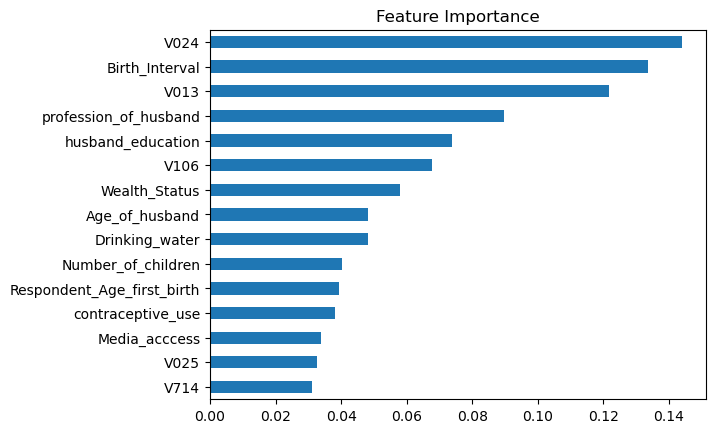

In [57]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=features)

feat_imp.sort_values().plot.barh()

plt.title("Feature Importance")
plt.show()